In [5]:
import numpy as np
import os
import sys
import matplotlib.pyplot as plt

module_path = os.path.abspath('../quantproteomicssimbox')
if module_path not in sys.path:
    sys.path.append(module_path)

from quantproteomicssimbox import protgen
from quantproteomicssimbox import experiment

TTHWWDEHKGRQRYMKKLQIMIPVDGQCKMMITRMWKYWP
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0.

(array([ 0.,  0.,  0.,  0., 10.,  0.,  0.,  0.]),
 array([5.5  , 5.625, 5.75 , 5.875, 6.   , 6.125, 6.25 , 6.375, 6.5  ]),
 <BarContainer object of 8 artists>)

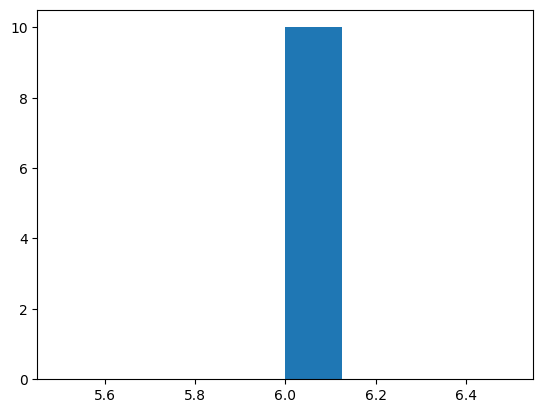

In [111]:
generator = protgen.ProteinGenerator()

protein = generator.generate_protein(40)
protein.set_quantification(10, miscleavage_rate=0.20)
print(protein.sequence)
print(protein.mod_table)
num_digestion_sites = len(protein.digestion_sites)
print(num_digestion_sites)
plt.hist(list(map(lambda x: len(x), protein.digestion_map)), bins=num_digestion_sites)

In [112]:

protein.digestion_sites, protein.digestion_map

([8, 10, 12, 15, 16, 28, 33, 36],
 [[8, 10, 15, 28, 33, 36],
  [8, 10, 12, 28, 33, 36],
  [10, 12, 15, 28, 33, 36],
  [8, 10, 15, 16, 28, 36],
  [8, 10, 12, 16, 28, 36],
  [8, 10, 12, 15, 28, 33],
  [12, 15, 16, 28, 33, 36],
  [8, 12, 15, 28, 33, 36],
  [8, 10, 12, 28, 33, 36],
  [10, 12, 15, 16, 33, 36]])

## Paper Explored Parameters
========================
 - Missingness: 0, 25, 50%
 - Number of Proteins: 5, 10
 - Total Abundance Per Protein: 100, 250
 - Length Proteins: 100, 200
 - Variance Level: 0, 1, 9
 - Incomplete Digestion Rate: 0, 25, 50%


In [75]:
missingness = 0
number_of_proteins = 10
total_abundance_per_protein = 250
length_proteins = 200
variance_level = 1
incomplete_digestion_rate = 0.5


In [76]:
rollups = ["rollup"]
aggregations = ["mean", "median", "sum"]

rmses = {} # {(scaling, aggregation): [rmses]}
n_repeats = 10

exp = experiment.Experiment(
    n_proteins=number_of_proteins,
    protein_length=length_proteins,
    n_subjects = 25,
    abundance = total_abundance_per_protein,
    miscleavage_rate = incomplete_digestion_rate,
    var_subject = variance_level,
    var_site = variance_level
    )

for i, scaling in enumerate(rollups):
    for j, aggregation in enumerate(aggregations):
        repeat_rmses = []
        for _ in range(n_repeats):
            exp.build()
            exp.observe()
            repeat_rmses.append(exp.score(scaling=scaling, aggregation=aggregation))
        rmses[(scaling, aggregation)] = np.array(repeat_rmses)
rmses


{('rollup',
  'mean'): array([1.1705375 , 1.28183881, 1.29866821, 1.12609708, 1.25593885,
        1.12364211, 1.22336718, 1.1267287 , 1.31161623, 1.36665024]),
 ('rollup',
  'median'): array([2.00424302, 1.72285359, 1.82173106, 1.82326704, 1.64453103,
        1.88252539, 1.91689107, 2.04791705, 1.92181884, 1.789463  ]),
 ('rollup',
  'sum'): array([0.41264175, 0.46094799, 0.41098948, 0.43843038, 0.36830529,
        0.30599507, 0.47666471, 0.3889126 , 0.50083793, 0.71927895])}

Text(0, 0.5, 'RMSE(log2FC)')

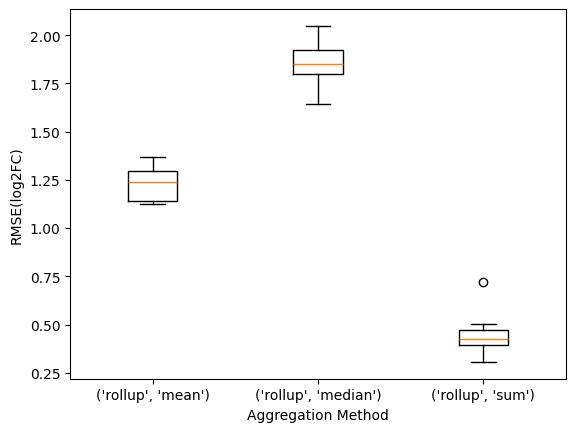

In [77]:
plt.boxplot(
    rmses.values(), 
    tick_labels=rmses.keys(),
    )
plt.xlabel("Aggregation Method")
plt.ylabel("RMSE(log2FC)")